# 1. IMPORT LIBRARIES
We will import all the libararies here

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# Display plots inside the notebook
%matplotlib inline

# Set a clean plotting style
sns.set_style("whitegrid")

# 2. LOAD DATASET 

In [5]:
df=pd.read_csv("../Dataset/USA_Housing.csv")

# 3. UNDERSTAND DATASET

In [6]:
# df.head()
# df.tail()
# df.shape
# df.columns
# df.info()
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


# 4. CLEANING DATASET

We will now check for missing values in each column

In [7]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

### Observation
Since there are no missing values we will check the duplicate values.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

### observation 
he dataset contains no duplicate rows, indicating that each observation is unique and no duplicate removal is required.  
All numerical features are float64 Address is a string column.

In [10]:
print("Negative values in Price:", (df["Price"] < 0).sum())
print("Negative values in Area Population:", (df["Area Population"] < 0).sum())

Negative values in Price: 0
Negative values in Area Population: 0


In [11]:
df=df.drop("Address",axis=1)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


# 5. EXPLORATORY DATA ANALYSIS (EDA)

We begin EDA by analyzing the target variable (Price). This helps us understand how house prices are distributed and whether the data is symmetric or skewed.

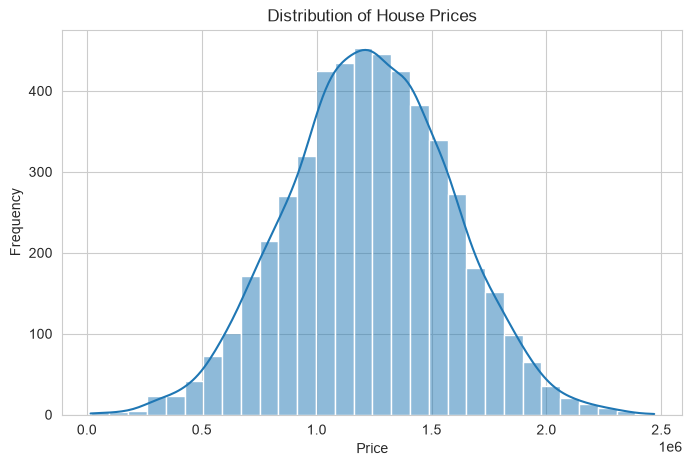

In [13]:
# HISTOGRAM FOR PRICE

plt.figure(figsize=(8,5))

sns.histplot(df["Price"] , bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

<Figure size 1500x1000 with 0 Axes>

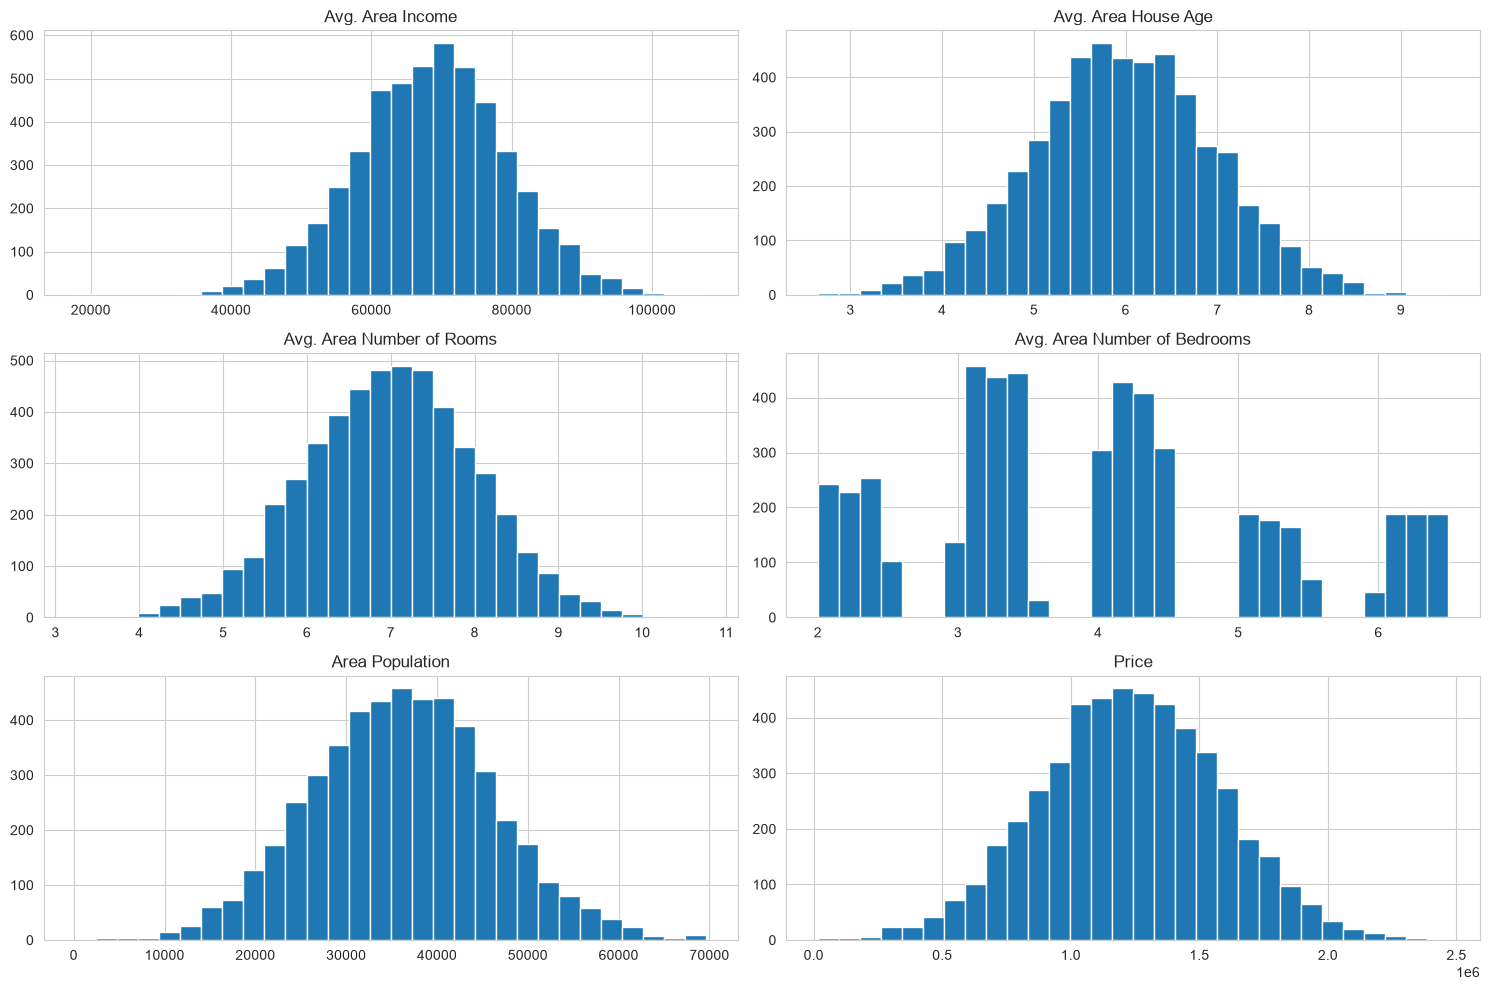

In [14]:
# HISTOGRAM FOR EACH COLUMN VALUE

plt.figure(figsize=(15,10))

df.hist(bins=30, figsize=(15,10))

plt.tight_layout()
plt.show()

### Observations

- Most numerical features follow an approximately normal (bell-shaped) distribution.
- The target variable (`Price`) is also approximately normally distributed with a slight positive skew.
- `Avg. Area Number of Bedrooms` does not follow a normal distribution and appears clustered because it is a count-based feature.
- No feature shows severe skewness or obvious extreme outliers from the histograms.

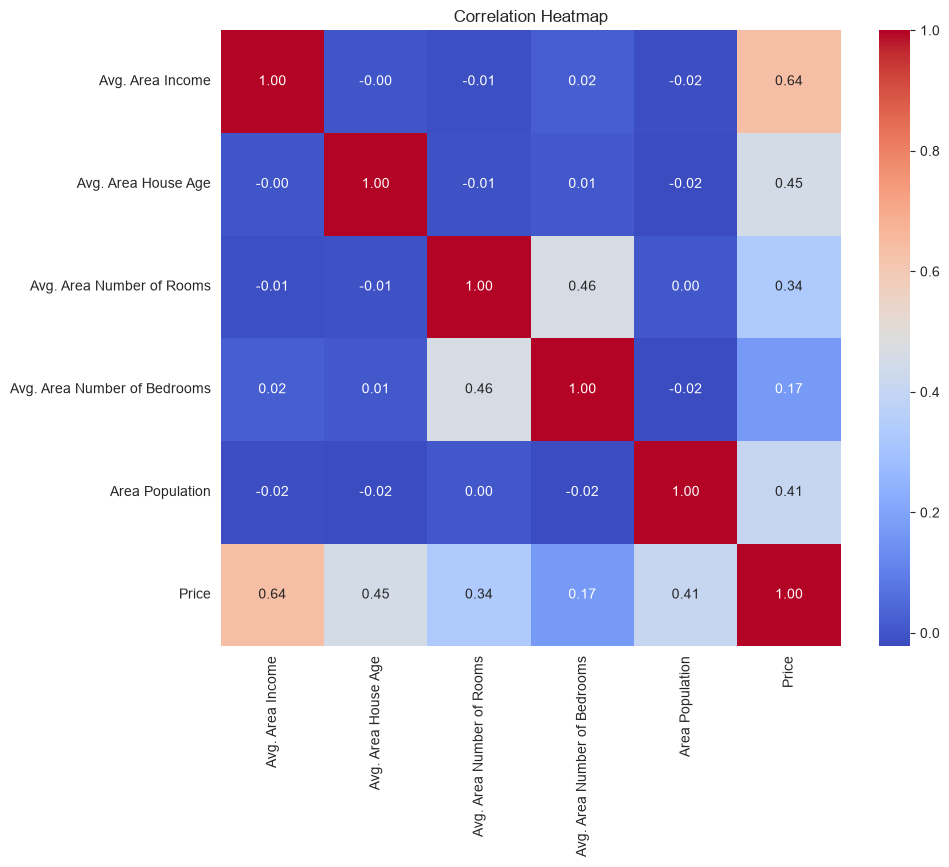

In [15]:
# HEATMAP

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observations

- `Avg. Area Income` has the strongest positive correlation with `Price` (0.64), indicating that areas with higher average incomes tend to have more expensive houses.
- `Avg. Area House Age` (0.45), `Area Population` (0.41), and `Avg. Area Number of Rooms` (0.34) show moderate positive correlations with the target variable.
- `Avg. Area Number of Bedrooms` has a weak positive correlation (0.17) with `Price`, suggesting it contributes less to predicting house prices on its own.
- Most independent features have correlations close to zero with one another, indicating no significant multicollinearity.
- The highest correlation among independent features is between `Avg. Area Number of Rooms` and `Avg. Area Number of Bedrooms` (0.46), which is moderate and not a concern.

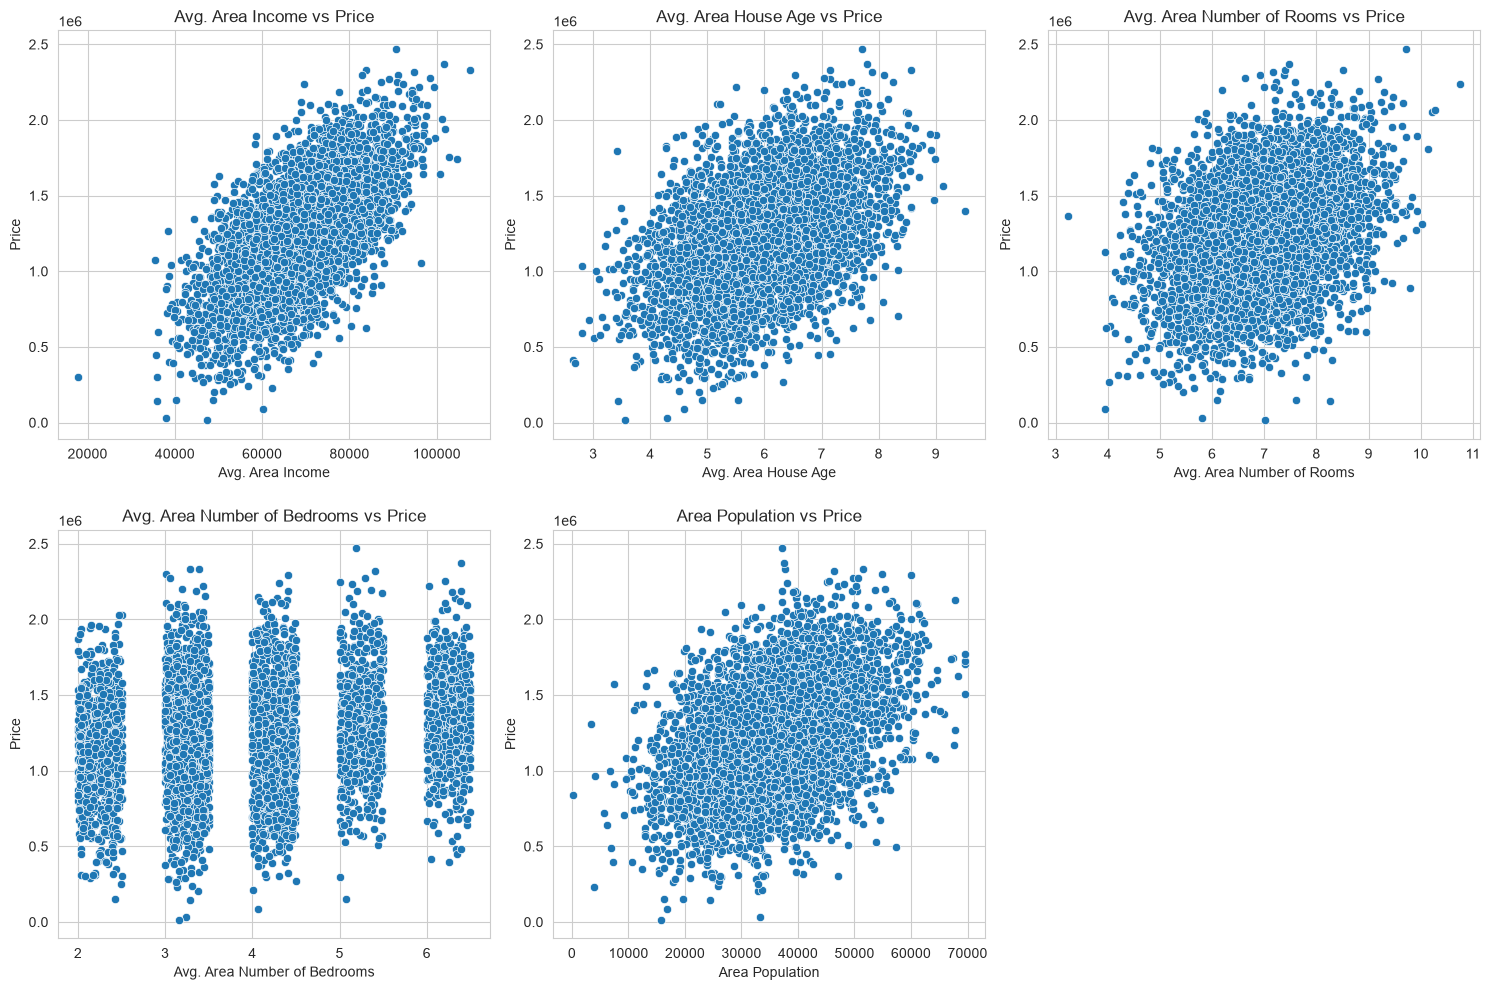

In [16]:
# SCATTER PLOT

features = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population"
]

plt.figure(figsize=(15,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[feature], y=df["Price"])
    plt.title(f"{feature} vs Price")

plt.tight_layout()
plt.show()

### Observations

- `Avg. Area Income` shows a strong positive linear relationship with `Price`, making it the most influential feature.
- `Avg. Area House Age`, `Avg. Area Number of Rooms`, and `Area Population` show moderate positive relationships with `Price`.
- `Avg. Area Number of Bedrooms` has a weak relationship with `Price` and displays vertical bands due to many repeated values.
- Most relationships appear approximately linear, suggesting that Linear Regression is a suitable model for this dataset.
- No major outliers or unusual patterns are observed in the scatter plots.

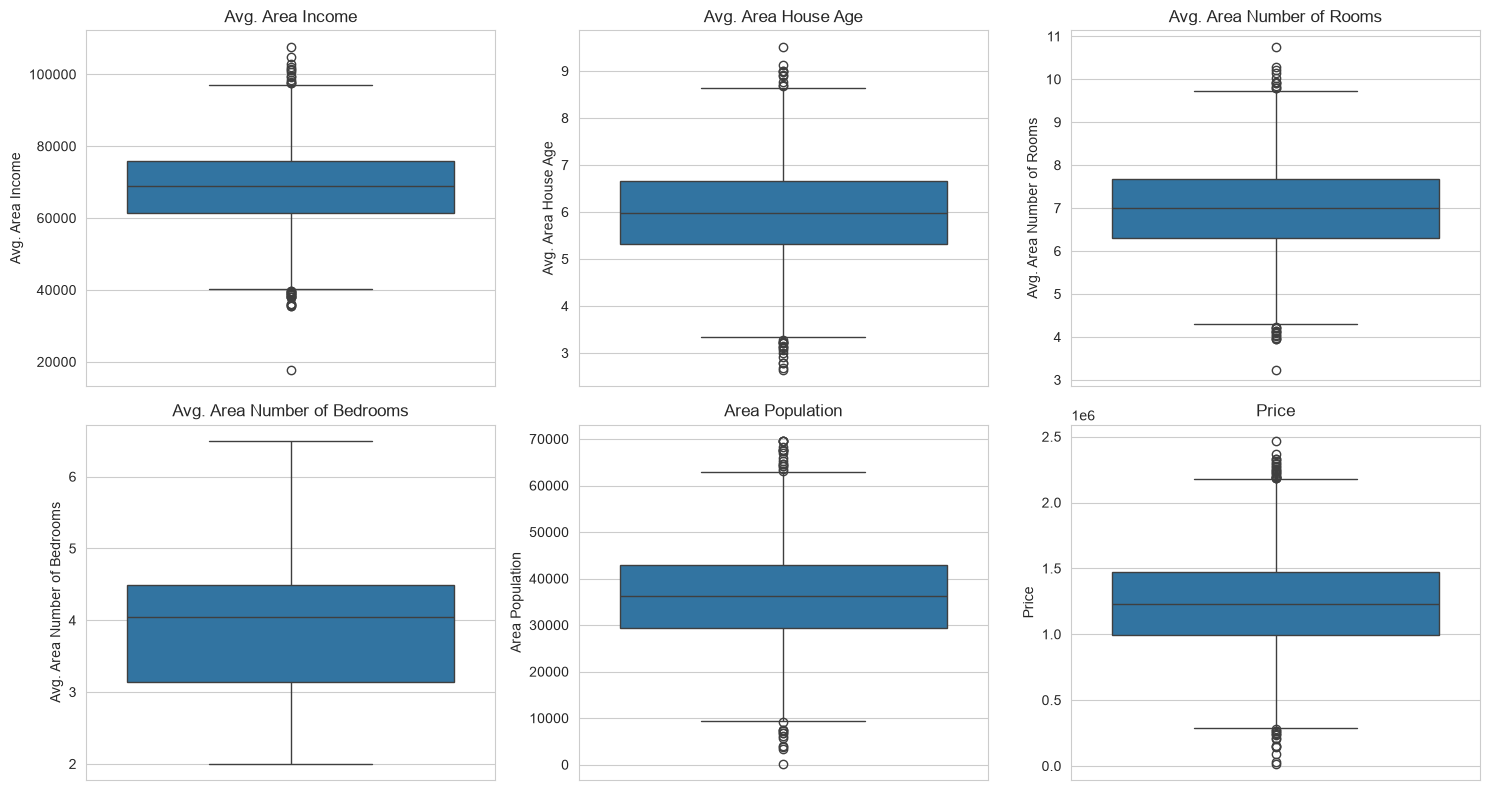

In [17]:
# OUTLIER DETECTION

plt.figure(figsize=(15,8))

for i, column in enumerate(df.columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

# 6. FEATURE ENGINEERING

Feature Engineering is the process of creating new features or transforming existing ones to improve the performance and interpretability of a machine learning model.

In this project, we will:

- Create a new feature called `rooms_per_bedroom`.
- Categorize `Area Population` into Low, Medium, and High groups.

In [18]:
df["rooms_per_bedroom"] = (
    df["Avg. Area Number of Rooms"] /
    df["Avg. Area Number of Bedrooms"]
)

df[["Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "rooms_per_bedroom"]].head()

,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,rooms_per_bedroom
0,7.009188,4.09,1.713738
1,6.730821,3.09,2.178259
2,8.512727,5.13,1.659401
3,5.586729,3.26,1.713720
4,7.839388,4.23,1.853283


In [19]:
df["population_category"] = pd.qcut(
    df["Area Population"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["Area Population", "population_category"]].head()

df["population_category"].value_counts()

population_category
Low       1667
High      1667
Medium    1666
Name: count, dtype: int64

# 7. FEATURE SELECTION

Feature Selection is the process of separating the input features (independent variables) from the target variable (dependent variable).

In this project:

- **Features (X):** All numerical variables used to predict house prices.
- **Target (y):** `Price`

The newly created `rooms_per_bedroom` feature is included in the model because it provides additional numerical information.

The `population_category` feature is excluded because it was created only for comparing the model's prediction performance across different population groups and is not used for training the Linear Regression model.

In [20]:
X = df.drop(["Price", "population_category"], axis=1)
y = df["Price"]

In [21]:
# Let's verify that the features and target variable have been separated correctly.

X.head()
y.head()

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

In [22]:
print(X.shape)
print(y.shape)

(5000, 6)
(5000,)


# 8. TRAIN-TEST SPLIT

The dataset is divided into training and testing sets.

- The training set is used to train the machine learning model.
- The testing set is used to evaluate the model's performance on unseen data.

This helps us determine how well the model generalizes to new data and prevents overfitting.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 6)
X_test shape: (1000, 6)
y_train shape: (4000,)
y_test shape: (1000,)


### Observation

The dataset has been successfully split into training and testing sets.

- Training set: 4000 observations (80%)
- Testing set: 1000 observations (20%)

The training data will be used to train the Linear Regression model, while the testing data will be used to evaluate its performance on unseen data.

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[-4.68070027e-16 -5.32907052e-18 -3.46389584e-17 -3.46389584e-17
  8.08242362e-17  1.47881707e-16]
[1. 1. 1. 1. 1. 1.]


# 9. MODEL TRAINING

In this step, we will train a Linear Regression model using the training dataset.

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values by finding the best-fitting linear relationship between the independent variables (features) and the dependent variable (target).

In [81]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[231741.57,163580.35,120610.87, 3239.35,152236.44, 229.73]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.23e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[88.71,64.34,63.35,63.13,61.98,12.33]"


In [82]:
import joblib

joblib.dump(model, "../Model/house_price_model.pkl")
joblib.dump(scaler, "../Model/scaler.pkl")

['../Model/scaler.pkl']

# 10. MAKE PREDICTIONS

After training the Linear Regression model, we use it to predict house prices for the testing dataset.

The predicted values will later be compared with the actual house prices to evaluate the model's performance.

In [83]:
predictions = model.predict(X_test_scaled)
predictions.shape

(1000,)

In [84]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

comparison.head()

,Actual Price,Predicted Price
1501,1.339096e+06,1.308538e+06
2586,1.251794e+06,1.237005e+06
2653,1.340095e+06,1.243661e+06
1055,1.431508e+06,1.228835e+06
705,1.042374e+06,1.063377e+06


### Observation

The trained Linear Regression model generated predictions for all 1000 observations in the testing dataset.

A comparison of the actual and predicted house prices shows that the predicted values are generally close to the actual values, indicating that the model has learned the underlying relationship between the features and the target variable.

# 11. MODEL EVALUATION

After training the Linear Regression model, we evaluate its performance using different regression evaluation metrics.

The metrics used are:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

These metrics help us understand how accurately the model predicts house prices.

In [85]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

In [86]:
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 80881.07
Mean Squared Error (MSE): 10089898690.08
Root Mean Squared Error (RMSE): 100448.49
R² Score: 0.9180


### Observation

The Linear Regression model achieved an R² score of approximately **0.918**, indicating that it explains about **91.8% of the variation** in house prices.

The MAE and RMSE values indicate that the model predicts house prices with relatively low error compared to the overall price range.

After adding the `rooms_per_bedroom` feature, the evaluation metrics changed only slightly, suggesting that this engineered feature did not significantly improve the model's predictive performance.

# 12. ACTUAL VS PREDICTED VALUES

After evaluating the model using numerical metrics, we visualize its performance by comparing the actual house prices with the predicted house prices.

If the predictions are accurate, the points should lie close to a straight diagonal line, indicating that the predicted values are close to the actual values.

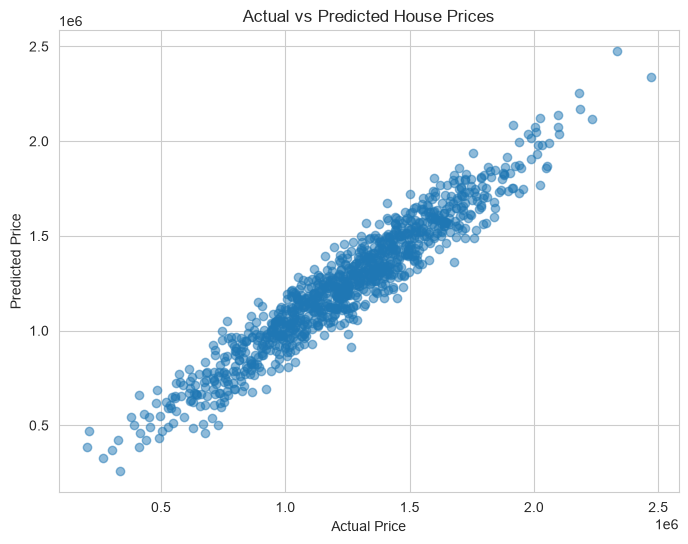

In [87]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions ,alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

### Observation

The scatter plot shows a strong positive relationship between the actual and predicted house prices. 
Most data points are closely clustered, indicating that the Linear Regression model predicts house prices with good accuracy. 
Although there are small differences between the actual and predicted values, no major deviations or unusual patterns are observed.

# 12. POPULATION CATEGORY COMPARISON

To evaluate whether the Linear Regression model performs equally well across different population levels, the prediction errors are compared for three population categories:

- Low
- Medium
- High

The categories were created earlier using `pd.qcut()`. The Mean Absolute Error (MAE) is calculated separately for each category to determine whether the model performs consistently across different population groups.

In [88]:
results = X_test.copy()
results["Actual Price"] = y_test
results["Predicted Price"] = predictions
results.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,rooms_per_bedroom,Actual Price,Predicted Price
1501,61907.593345,7.017838,6.440256,3.25,43828.947207,1.981617,1.339096e+06,1.308538e+06
2586,57160.202243,6.893260,6.921532,3.13,43467.147035,2.211352,1.251794e+06,1.237005e+06
2653,70190.796445,6.745054,6.662567,2.01,29215.136112,3.314710,1.340095e+06,1.243661e+06
1055,69316.796889,6.300409,7.873576,4.28,24448.211461,1.839621,1.431508e+06,1.228835e+06
705,72991.481649,3.412866,6.494081,2.48,50626.495426,2.618581,1.042374e+06,1.063377e+06


In [89]:
results["Population Category"] = df.loc[X_test.index, "population_category"]
results.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,rooms_per_bedroom,Actual Price,Predicted Price,Population Category
1501,61907.593345,7.017838,6.440256,3.25,43828.947207,1.981617,1.339096e+06,1.308538e+06,High
2586,57160.202243,6.893260,6.921532,3.13,43467.147035,2.211352,1.251794e+06,1.237005e+06,High
2653,70190.796445,6.745054,6.662567,2.01,29215.136112,3.314710,1.340095e+06,1.243661e+06,Low
1055,69316.796889,6.300409,7.873576,4.28,24448.211461,1.839621,1.431508e+06,1.228835e+06,Low
705,72991.481649,3.412866,6.494081,2.48,50626.495426,2.618581,1.042374e+06,1.063377e+06,High


## Calculating Prediction Error

To compare the model's performance across population categories, we first calculate the absolute prediction error for each house.

The absolute error is the absolute difference between the actual price and the predicted price.

In [90]:
results["Absolute Error"] = abs(results["Actual Price"] - results["Predicted Price"])
results.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,rooms_per_bedroom,Actual Price,Predicted Price,Population Category,Absolute Error
1501,61907.593345,7.017838,6.440256,3.25,43828.947207,1.981617,1.339096e+06,1.308538e+06,High,30558.535476
2586,57160.202243,6.893260,6.921532,3.13,43467.147035,2.211352,1.251794e+06,1.237005e+06,High,14789.578615
2653,70190.796445,6.745054,6.662567,2.01,29215.136112,3.314710,1.340095e+06,1.243661e+06,Low,96434.238694
1055,69316.796889,6.300409,7.873576,4.28,24448.211461,1.839621,1.431508e+06,1.228835e+06,Low,202672.491689
705,72991.481649,3.412866,6.494081,2.48,50626.495426,2.618581,1.042374e+06,1.063377e+06,High,21003.846637


## Comparing Average Prediction Error by Population Category

The Mean Absolute Error (MAE) is calculated separately for each population category (Low, Medium, and High). This helps determine whether the model performs consistently across different population levels.

In [91]:
category_error = results.groupby("Population Category")["Absolute Error"].mean()

print(category_error)

Population Category
Low       80626.647503
Medium    80982.433760
High      81022.410862
Name: Absolute Error, dtype: float64


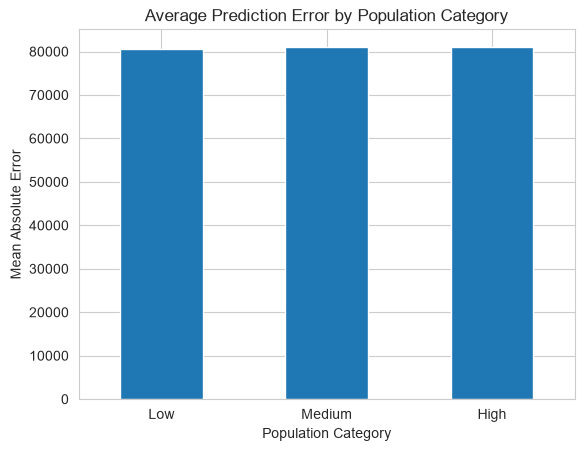

In [92]:
category_error.plot(kind="bar")

plt.title("Average Prediction Error by Population Category")
plt.xlabel("Population Category")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=0)

plt.show()